In [32]:
#Metodologia ASUM DM

#Entendimiento del negocio: Aerolinea que busca entender a sus clientes en particular, el objetivo de negocio es entender las difernecias 
#clientes para ofrecer modelos diferenciados de actuacion

#Enfoque analitico: Diseñar un experimento que permita agrupar en una catnidad específica de grupos a los clientes de la aerolinea para definir
# la cantidad ade acciones diferenciadas ´posibles

#Requerimiento de datos: Los del csv, demograficos , servicios prestados del usario, datos del negocio

#Recoleccion: 



In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt, seaborn as sb
import warnings
warnings.filterwarnings('ignore')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.pipeline import Pipeline  # ¡Corregido aquí!




In [34]:
data = pd.read_csv("airline_loyalty(in).csv")

data

data = data.sample(2500)

In [35]:

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 51879 to 49435
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         2500 non-null   int64  
 1   id                                 2500 non-null   int64  
 2   Gender                             2500 non-null   object 
 3   Customer Type                      2500 non-null   object 
 4   Age                                2500 non-null   int64  
 5   Type of Travel                     2500 non-null   object 
 6   Class                              2500 non-null   object 
 7   Flight Distance                    2500 non-null   int64  
 8   Inflight wifi service              2500 non-null   int64  
 9   Departure/Arrival time convenient  2500 non-null   int64  
 10  Ease of Online booking             2500 non-null   int64  
 11  Gate location                      2500 non-null   int64

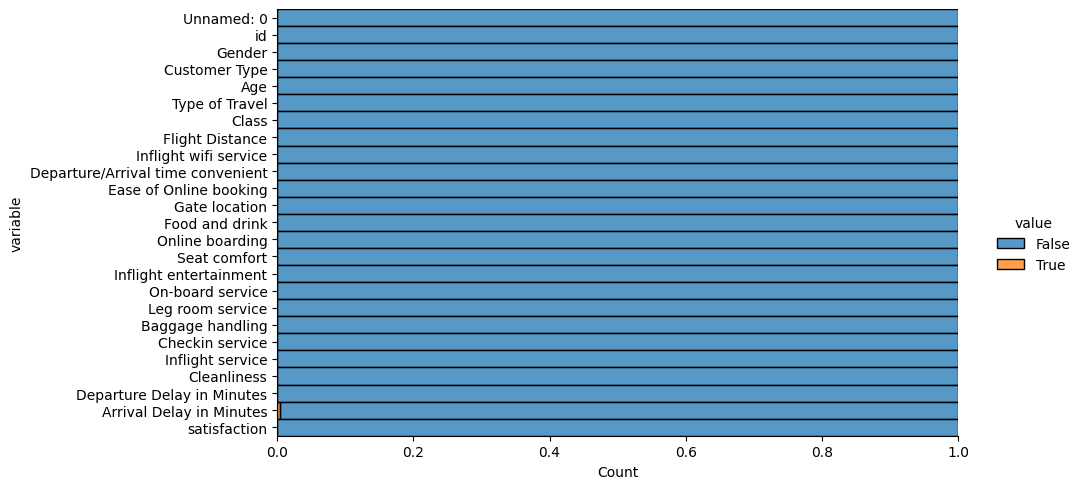

In [36]:
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y ='variable', hue = 'value', multiple = 'fill', aspect=2))



In [37]:
#eliminamos registros cuando la proporcion de eliminacion no supera el 10% de los registros orginales, eliminamos variables cuando la proporcion 

#de nulos supera el 40%, variables sonm las columnas los registros son las filas

#imputacion simple:  Se define un valor para completar por variable, con medidas de tendencia central


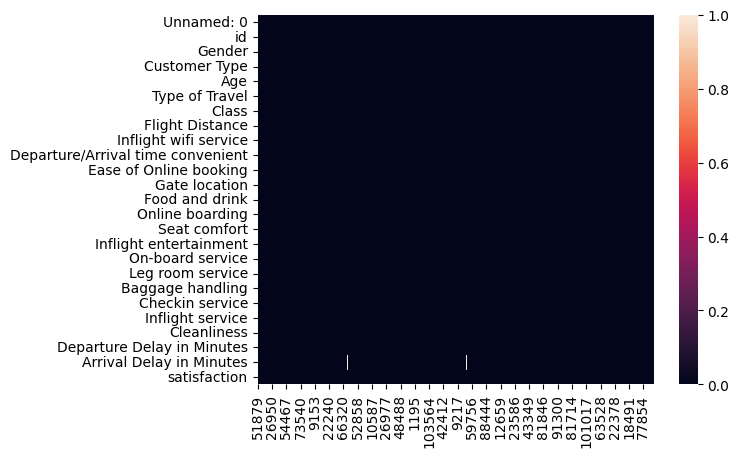

In [38]:
plt.Figure(figsize=(12,12))

data.isnull().transpose().pipe(lambda df: sb.heatmap(data=df))

plt.show()

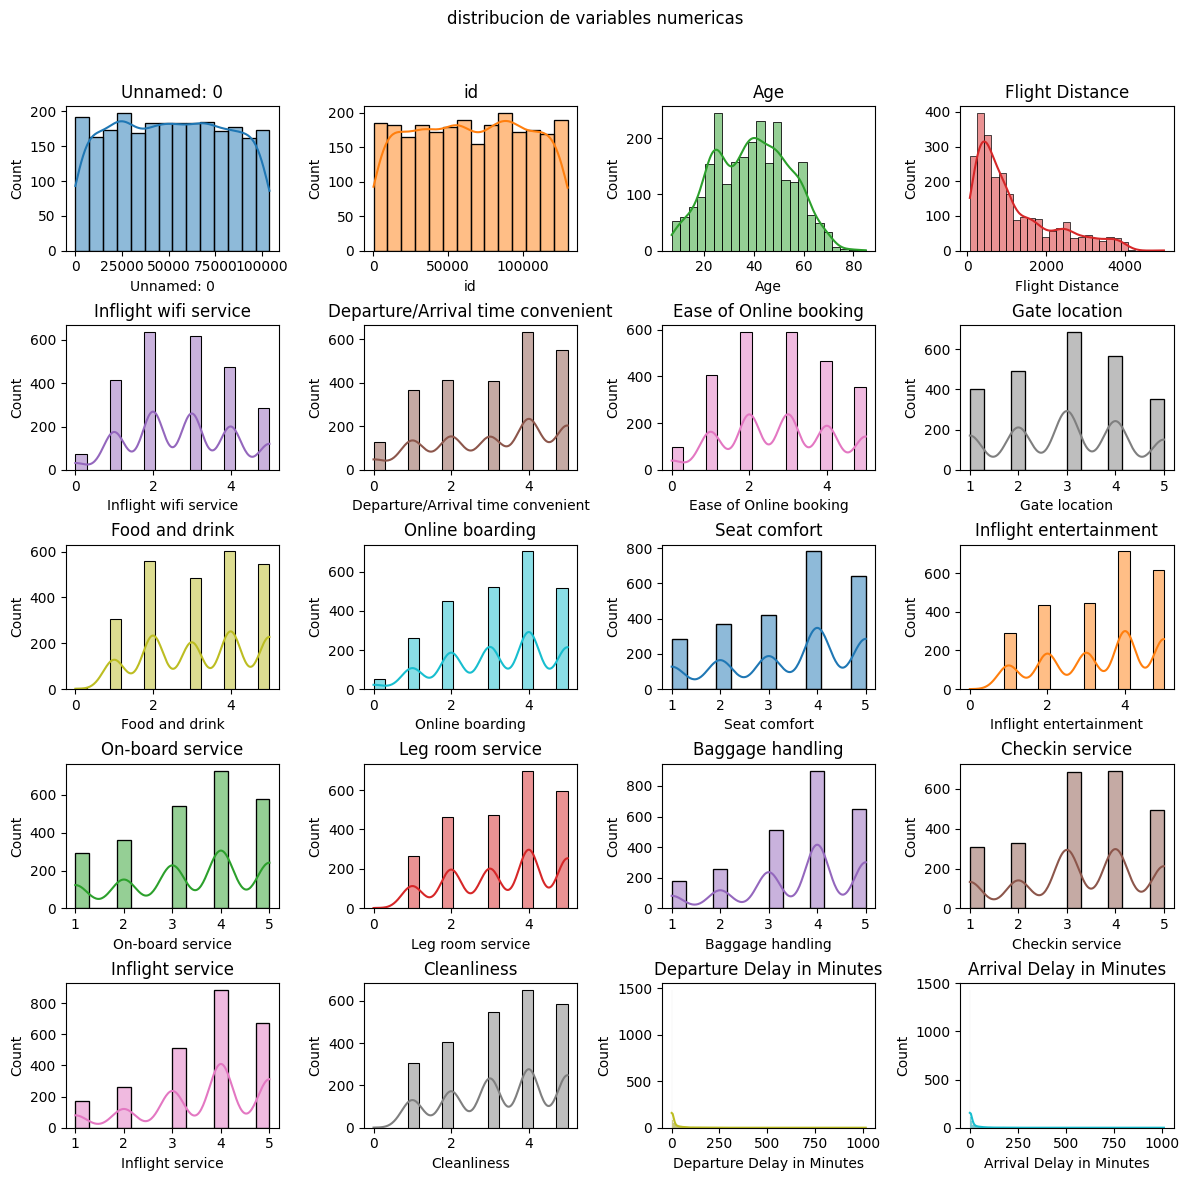

In [39]:
fig, ax = plt.subplots(5,4,figsize =(12,12))

ax = ax.flat
num_col = data.select_dtypes(include= ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.histplot(data = data, x =col, kde = True, color = (list(plt.rcParams['axes.prop_cycle'])*7)[i]['color'], ax =ax[i])
    ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('distribucion de variables numericas')

plt.show()

In [40]:
print(data.columns.tolist())

['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


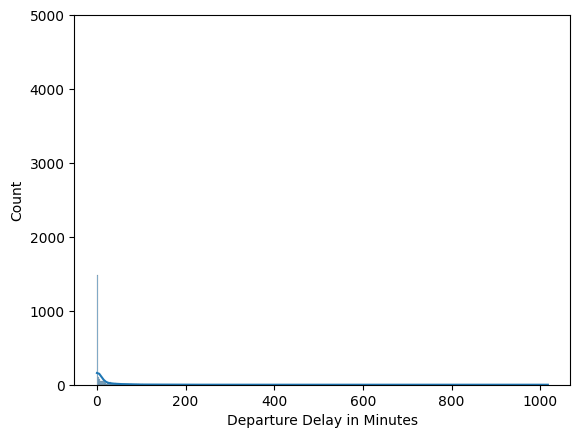

In [41]:
sb.histplot(data = data, x =data['Departure Delay in Minutes'], kde = True)

plt.ylim(0,5000)
plt.show()

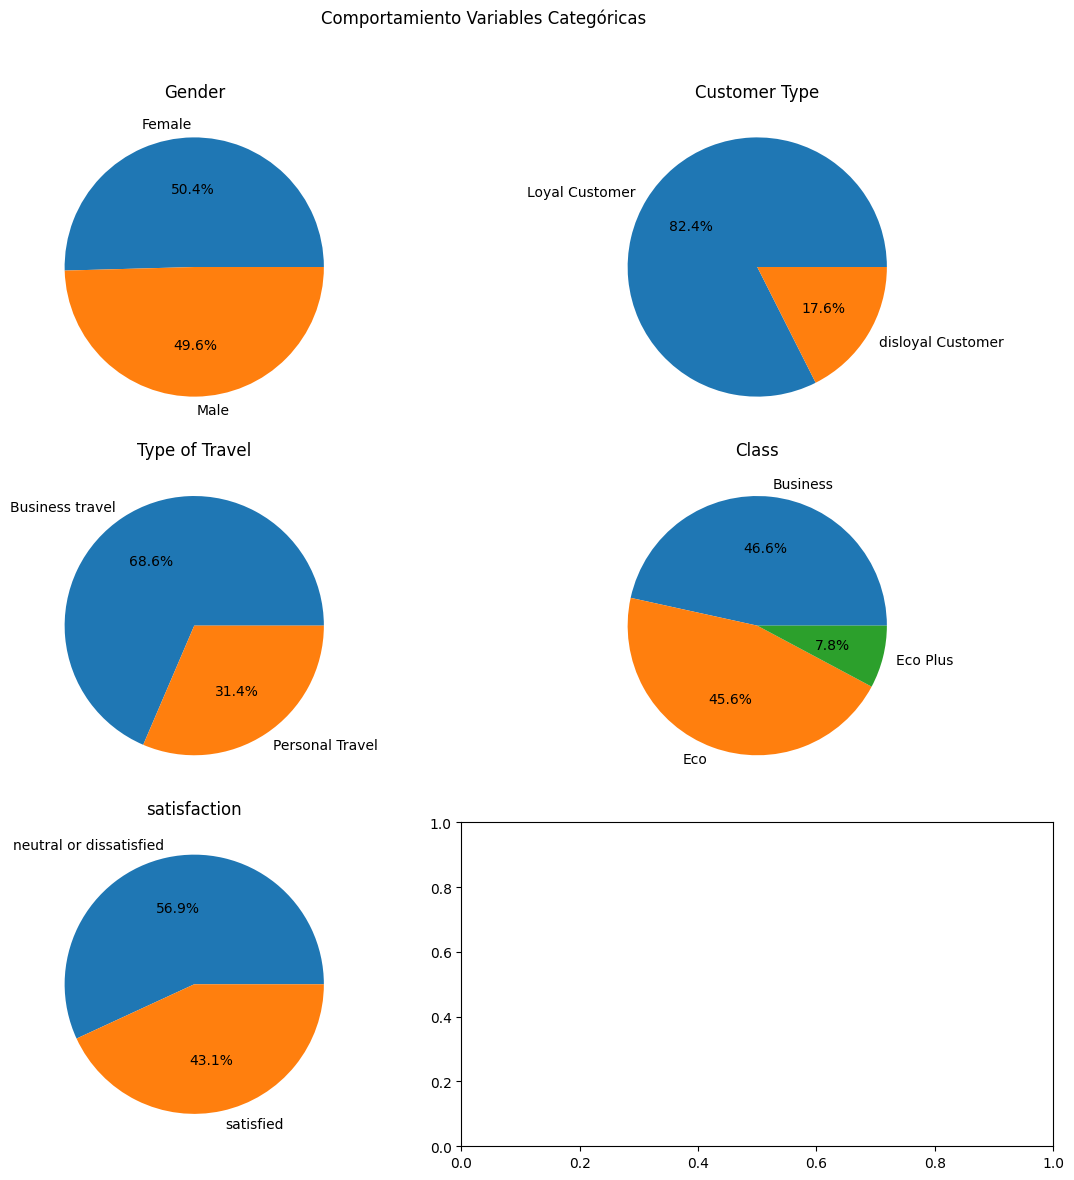

In [42]:
fig, ax = plt.subplots(3,2,figsize =(12,12))
ax = ax.flat
cat_col = data.select_dtypes(include=['object']).columns

for i,col in enumerate(cat_col):
    ax[i].pie(x=data[col].value_counts(),labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")

plt.show()

In [43]:
#ignorar el id CustomerType

#correlacion nula : -0.25 y 0.25

#directa: 0 y 1, inversa 0 y -1

# debil : 0.25<abs(p)<0.5
#moderada : 0.5<abs(p)<0.75
#fuerte : 0.75<abs(p)<1


#multicolinealidad se trabaja dent5ro de la fuerte

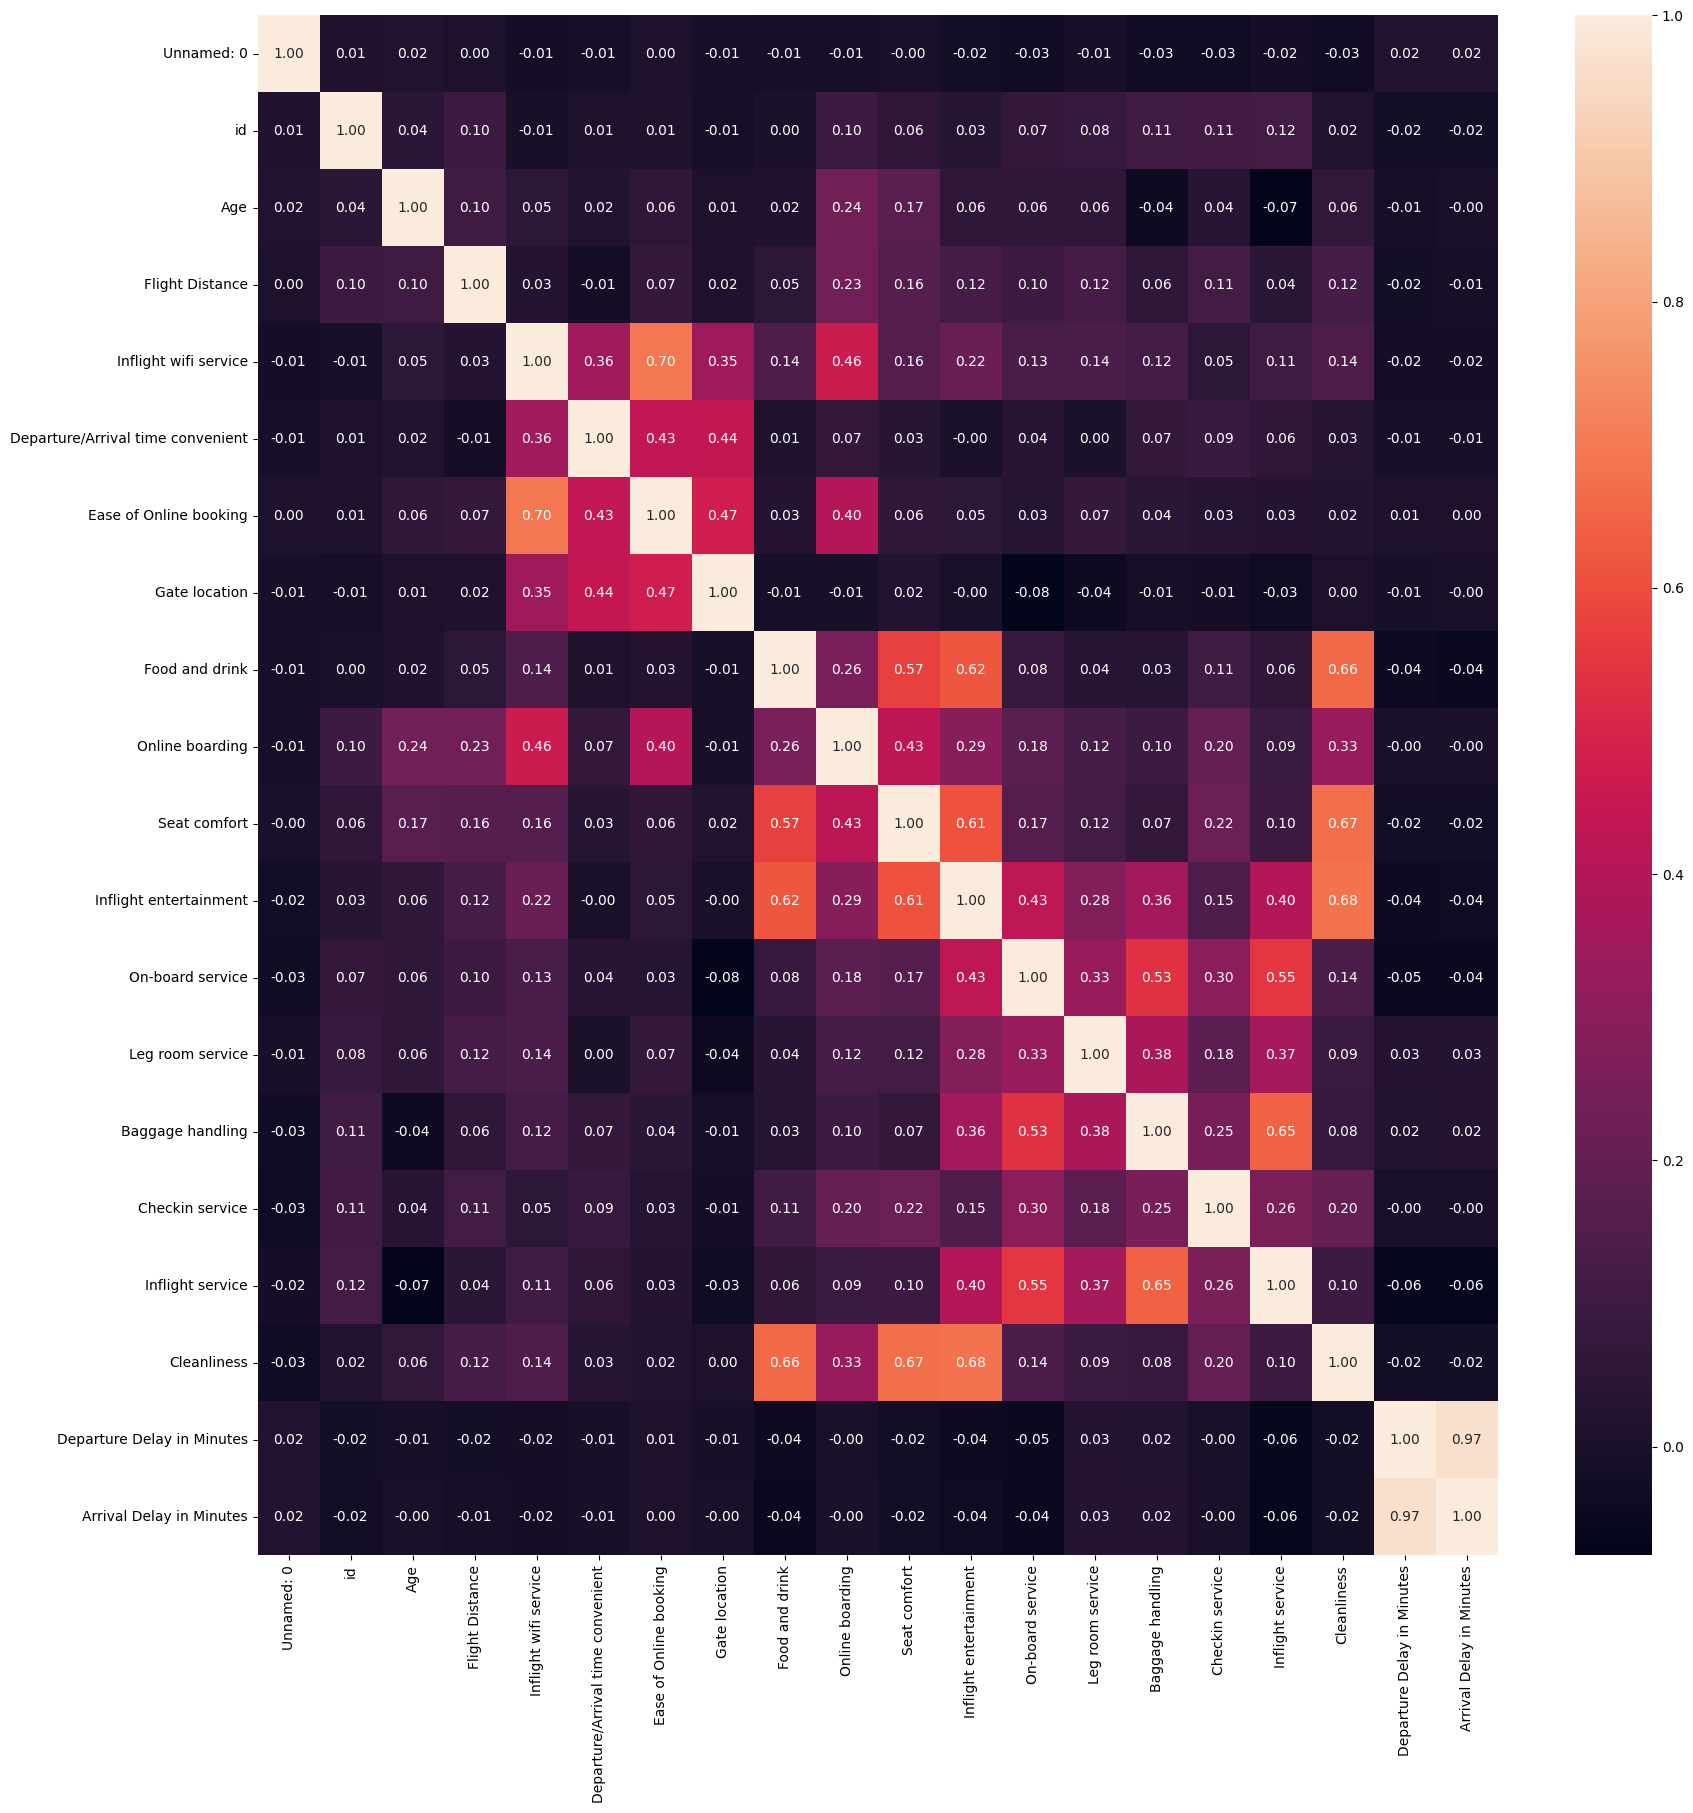

In [44]:
#Gráfico de correlacion paara analisis multivariado

plt.figure(figsize=(20,20))

sb.heatmap(data = data.corr(numeric_only=True), annot = True, fmt = '.2f')

plt.show()

In [45]:
#ignorar tambien arrival delay in minutes
#6.preparacion de los datos

# actiuvar las decisiones de ignorar variables

# transformacion de variables para que sean entendibles por el modelo

In [46]:
data_mod = data.drop(['Unnamed: 0', 'id', 'Customer Type','Arrival Delay in Minutes'],axis=1)
data_mod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2500 entries, 51879 to 49435
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Gender                             2500 non-null   object
 1   Age                                2500 non-null   int64 
 2   Type of Travel                     2500 non-null   object
 3   Class                              2500 non-null   object
 4   Flight Distance                    2500 non-null   int64 
 5   Inflight wifi service              2500 non-null   int64 
 6   Departure/Arrival time convenient  2500 non-null   int64 
 7   Ease of Online booking             2500 non-null   int64 
 8   Gate location                      2500 non-null   int64 
 9   Food and drink                     2500 non-null   int64 
 10  Online boarding                    2500 non-null   int64 
 11  Seat comfort                       2500 non-null   int64 
 12  Inflig

In [47]:
num_col = data_mod.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_col = data_mod.select_dtypes(include=['object']).columns.to_list()

# Pipelines corregidos (usando Pipeline con mayúscula)
num_transformer = Pipeline(steps=[('scaler', MinMaxScaler())])
cat_transformer = Pipeline(steps=[('encoder', OneHotEncoder())])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col),
        ('cat', cat_transformer, cat_col)
    ],
    remainder='passthrough'
)

In [48]:
data_pre = preprocessor.fit_transform(data_mod)
data_pre

array([[0.62820513, 0.03193653, 0.4       , ..., 0.        , 1.        ,
        0.        ],
       [0.75641026, 0.19467046, 0.4       , ..., 0.        , 1.        ,
        0.        ],
       [0.32051282, 0.06224573, 0.2       , ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.41025641, 0.16415785, 1.        , ..., 0.        , 0.        ,
        1.        ],
       [0.55128205, 0.10821806, 0.8       , ..., 0.        , 0.        ,
        1.        ],
       [0.64102564, 0.27644426, 0.8       , ..., 0.        , 0.        ,
        1.        ]], shape=(2500, 26))

In [49]:
cod_cat = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_col)

labels = np.concatenate([num_col, cod_cat])

data_pro = pd.DataFrame(data_pre,columns = labels)

data_pro.head()




,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Departure Delay in Minutes,Gender_Female,Gender_Male,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus,satisfaction_neutral or dissatisfied,satisfaction_satisfied
0,0.628205,0.031937,0.4,0.8,0.4,0.50,0.6,0.4,0.50,0.6,...,0.000000,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.756410,0.194670,0.4,1.0,0.4,0.75,0.6,0.4,0.50,0.6,...,0.000983,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.320513,0.062246,0.2,0.8,0.2,0.00,0.8,0.2,0.75,0.8,...,0.003933,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.666667,0.021562,0.8,0.8,1.0,0.75,0.8,0.8,1.00,1.0,...,0.000000,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.371795,0.102522,0.2,0.2,0.2,0.00,0.8,0.4,1.00,1.0,...,0.000000,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [50]:
#Clase 3


#K means: Determinar un valor para k (grupos)
#Técnica del codo


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score



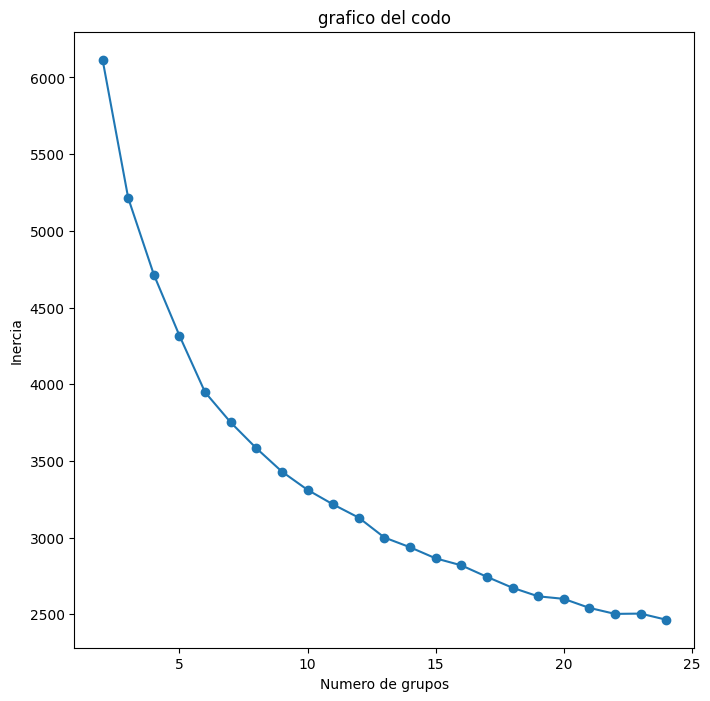

In [51]:
range_k = range(2,25)

inertia =[]

for n_clusters in range_k:
    kmeans_model = KMeans(n_clusters = n_clusters, n_init=20, random_state = 123)

    kmeans_model.fit(data_pro)
    inertia.append(kmeans_model.inertia_)

plt.figure(figsize = (8,8))

plt.plot(range_k,inertia,marker = 'o')

plt.title('grafico del codo')

plt.xlabel('Numero de grupos')
plt.ylabel('Inercia')

plt.show()

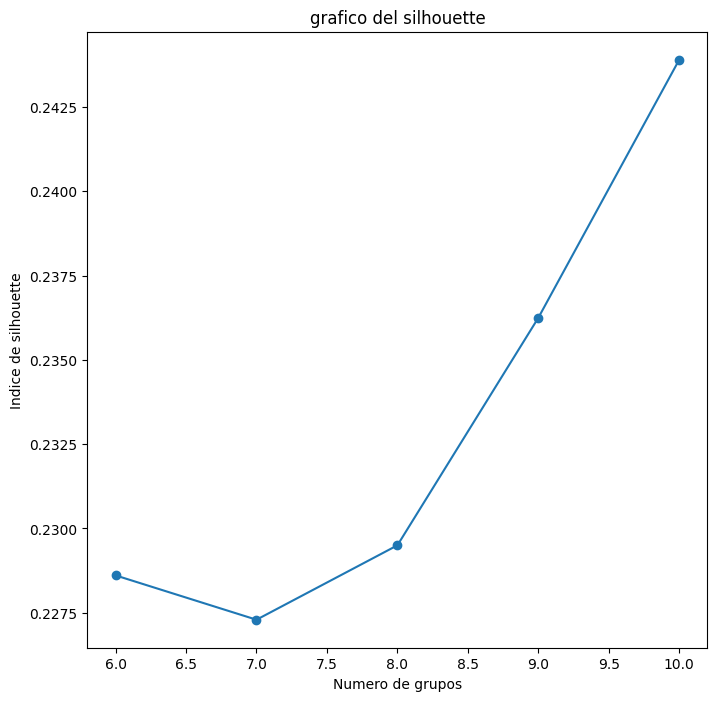

In [52]:
range_k = range(6,11)
sil_score =[]

for n_clusters in range_k:
    kmeans_model = KMeans(n_clusters=n_clusters, n_init=20, random_state=123)
    kmeans_model.fit(data_pro)
    cluster_label = kmeans_model.fit_predict(data_pro)
    sil_avg=silhouette_score(data_pro,cluster_label)
    sil_score.append(sil_avg) 

plt.figure(figsize = (8,8))

plt.plot(range_k,sil_score,marker = 'o')

plt.title('grafico del silhouette')

plt.xlabel('Numero de grupos')
plt.ylabel('Indice de silhouette')

plt.show()



In [53]:
kmeans_model_final = KMeans(n_clusters=10, n_init=20,random_state=123)

kmeans_model_final.fit(data_pro)

,n_clusters,10
,init,'k-means++'
,n_init,20
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,123
,copy_x,True
,algorithm,'lloyd'


In [54]:
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram



In [55]:
#funcion para dibujar dendograma


def dibujarDendrograma(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
 
    linkage_matrix = np.column_stack([model.children_, model.distances_, counts]).astype(float)
 
    # Plot
    dendrogram(linkage_matrix, **kwargs)

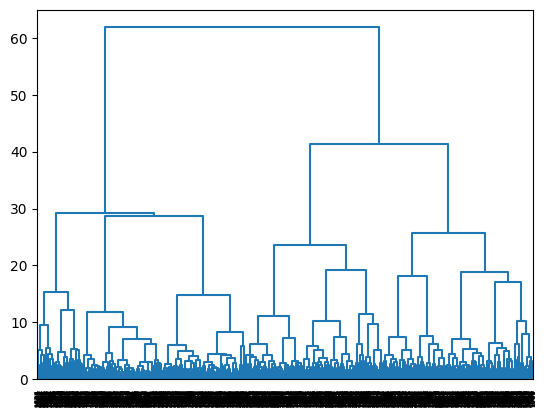

In [56]:
#Varianza

h_clust_ward = AgglomerativeClustering(metric='euclidean', linkage='ward', distance_threshold=0,n_clusters=None)

h_clust_ward.fit(X=data_pro)

dibujarDendrograma(h_clust_ward, color_threshold=0)


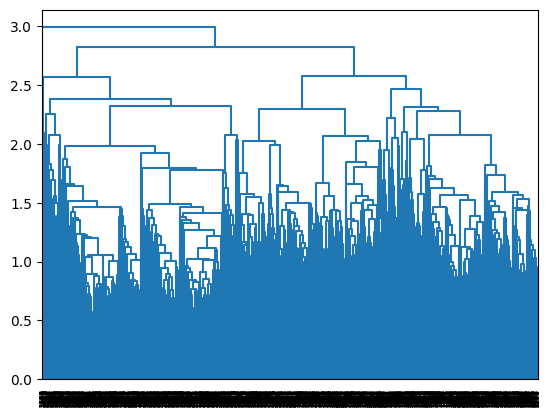

In [57]:
#promedio

h_clust_mean = AgglomerativeClustering(metric='euclidean', linkage='average',distance_threshold=0,n_clusters=None)

h_clust_mean.fit(X=data_pro)

dibujarDendrograma(h_clust_mean,color_threshold=0)






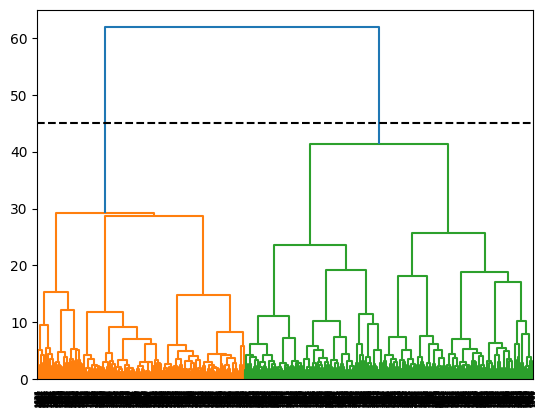

In [58]:
dendogram_prun = 45 # esto  fue la mitad del sample de 2000, cambiar

dibujarDendrograma(h_clust_ward,color_threshold = dendogram_prun)
plt.axhline(y=dendogram_prun,c = 'black', linestyle = '--')

plt.show()

In [59]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import  NearestNeighbors
from itertools import product



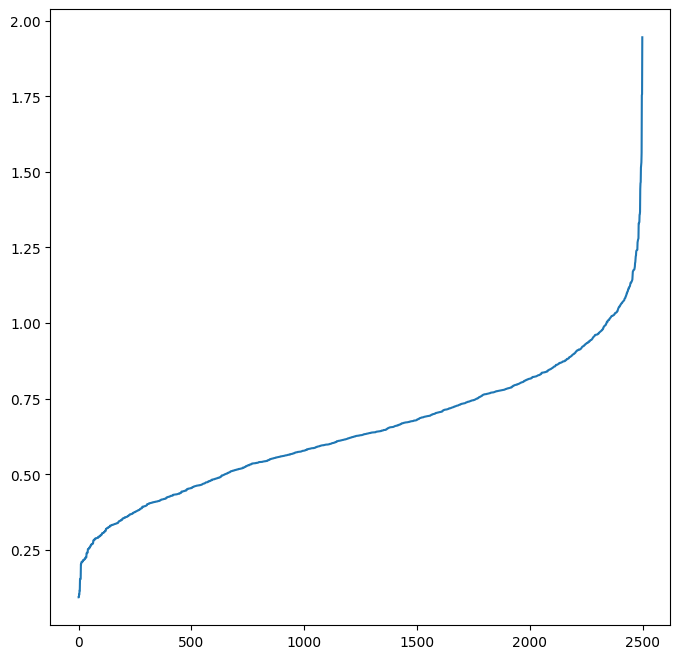

In [60]:
neighbors = NearestNeighbors(n_neighbors=3)

neighbors_fit = neighbors.fit(data_pro)

distance,index = neighbors_fit.kneighbors(data_pro)
distance=np.sort(distance,axis=0)

distance = distance[:,1]
plt.figure(figsize=(8,8))

plt.plot(distance)
plt.show()

In [65]:
h_clust_final = AgglomerativeClustering(metric='euclidean', linkage= 'ward', n_clusters=2)

h_clust_final.fit(data_pro)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [70]:
eps_values = np.arange(1.0,1.6,0.1)


min_samples = np.arange(2,10)

dbscan_params = list(product(eps_values,min_samples))

sil_score =[]

for p in dbscan_params:
    y_pred = DBSCAN(eps=p[0],min_samples=p[1]).fit_predict(data_pro)
    sil_score.append(silhouette_score(data_pro,y_pred))
    

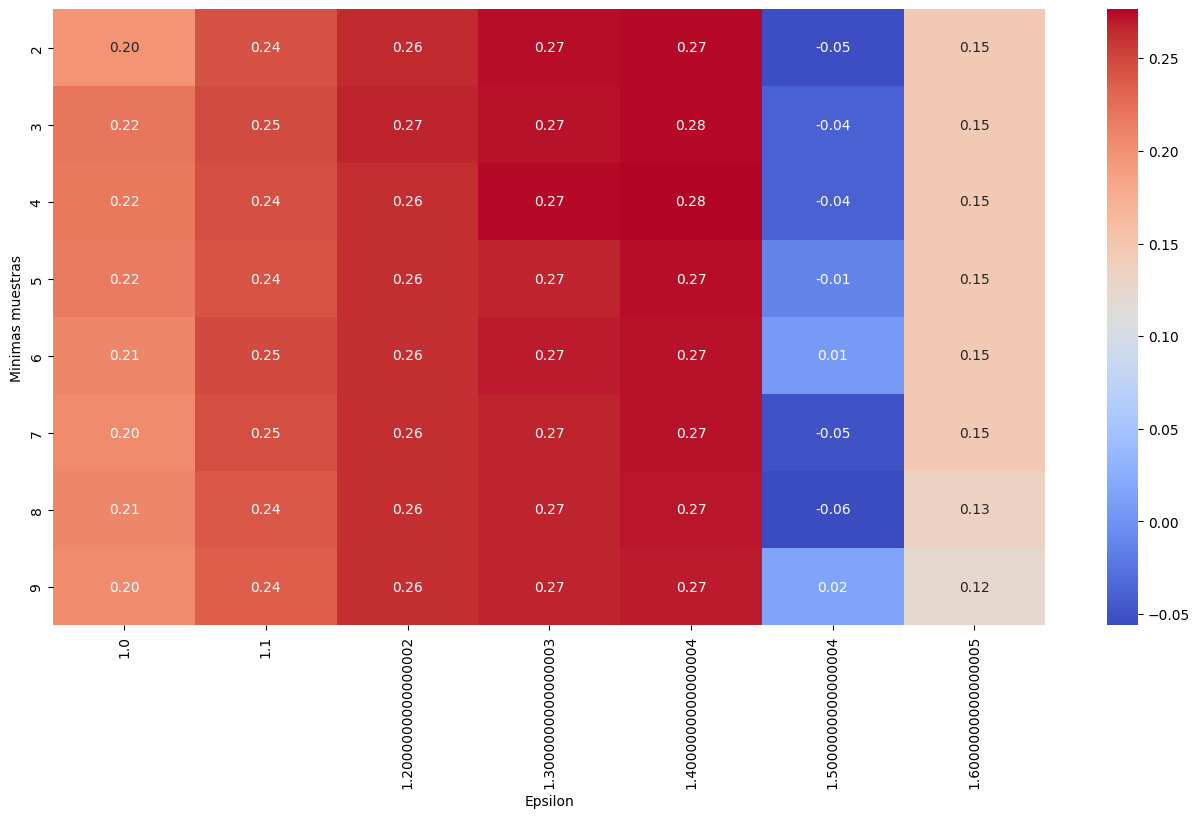

In [71]:
df_param_adj = pd.DataFrame.from_records(dbscan_params,columns=['Epsilon', 'Minimas muestras'])

df_param_adj['Score'] = sil_score

pivot_data = pd.pivot_table(df_param_adj,values = 'Score',index = 'Minimas muestras',columns='Epsilon')

plt.figure(figsize=(16,8))

sb.heatmap(pivot_data,annot=True,fmt='.2f',cmap='coolwarm')


plt.show()


In [88]:
dbscan_final = DBSCAN(eps = 1.3,min_samples=3)

dbscan_final.fit(data_pro)

,eps,1.3
,min_samples,3
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


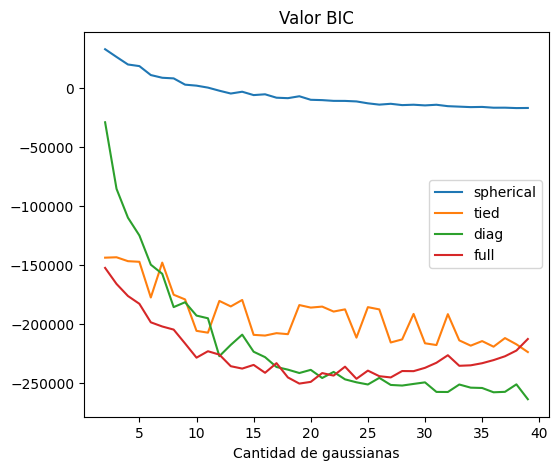

In [90]:
#Gaussian mixture models

from sklearn.mixture import GaussianMixture

fig, ax = plt.subplots(figsize=(6,5))
n_gauss = range(2,40)
var_types = ['spherical', 'tied', 'diag', 'full']

for covariance_type in var_types:

    valor_bic =[]
    for i in n_gauss:
        modelo = GaussianMixture(n_components=i,covariance_type=covariance_type)
        modelo = modelo.fit(data_pro)
        valor_bic.append(modelo.bic(data_pro))
    ax.plot(n_gauss,valor_bic,label=covariance_type)

ax.set_title('Valor BIC')

ax.set_xlabel('Cantidad de gaussianas')

ax.legend()
plt.show()






In [91]:
gmm_final = GaussianMixture(n_components=15,covariance_type='full')

gmm_final.fit(data_pro)

,n_components,15
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [92]:
labels_kmeans = kmeans_model_final.predict(data_pro)

labels_h_clust = h_clust_final.fit_predict(data_pro)

labels_dbscan = dbscan_final.fit_predict(data_pro)
labels_gmm=gmm_final.predict(data_pro)

In [98]:
sil_kmeans = silhouette_score(data_pro,labels_kmeans)

sil_h_clust = silhouette_score(data_pro,labels_h_clust)

sil_dbscan = silhouette_score(data_pro,labels_dbscan)

sil_gmm = silhouette_score(data_pro,labels_gmm)

print(f'el indice de silhouette para: \nKmeans = {round(sil_kmeans,2)}\nJerarquico = {round(sil_h_clust,2)}\nDBSCAN = {round(sil_dbscan,2)}\nGMM = {round(sil_gmm,2)}')

el indice de silhouette para: 
Kmeans = 0.24
Jerarquico = 0.23
DBSCAN = 0.27
GMM = 0.14


In [96]:
np.unique(labels_dbscan)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22])

In [103]:
data_pro['DBSCAN']=labels_dbscan

In [104]:
data_pro.DBSCAN.value_counts()

DBSCAN
 5     413
 3     404
 1     294
 7     265
 0     199
 2     167
 4     151
 13    145
 8      71
 9      66
 18     51
 12     43
 16     41
 10     38
 14     35
 15     32
-1      21
 11     20
 6      12
 19     12
 17     11
 21      3
 22      3
 20      3
Name: count, dtype: int64